### 02. Exploratory Data Analysis - Automobile Loan Default Prediction
 

#### 1. Setup




In [1]:
#import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Relative path handling: works whether launched from the workspace root or inside the notebooks folder
data_path = 'data/raw/Train_Dataset.csv' if os.path.exists('data/raw/Train_Dataset.csv') else '../data/raw/Train_Dataset.csv'

df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset loaded successfully from: '{data_path}'")
print(f"Shape: {df.shape}")

Dataset loaded successfully from: '../data/raw/Train_Dataset.csv'
Shape: (121856, 40)


In [3]:
# Columns identified in 01_data_understanding.ipynb as numeric-looking but stored as text
# because of stray non-numeric characters ('$', 'x', '&', '#VALUE!', '@', '#')
candidate_numerical_cols = [
    'Client_Income',
    'Credit_Amount',
    'Loan_Annuity',
    'Population_Region_Relative',
    'Age_Days',
    'Employed_Days',
    'Registration_Days',
    'ID_Days',
    'Score_Source_3'
]

# Work on a copy so the raw df stays untouched
eda_df = df.copy()

extra_nans_introduced = {}
for col in candidate_numerical_cols:
    before_missing = eda_df[col].isna().sum()
    eda_df[col] = pd.to_numeric(eda_df[col], errors='coerce')
    after_missing = eda_df[col].isna().sum()
    extra_nans_introduced[col] = after_missing - before_missing

print("Extra NaNs introduced per column by coercing invalid text to NaN:")
for col, n in extra_nans_introduced.items():
    print(f"  {col:30s}: {n}")

print(f"\neda_df dtypes for these columns are now:")
print(eda_df[candidate_numerical_cols].dtypes)

Extra NaNs introduced per column by coercing invalid text to NaN:
  Client_Income                 : 15
  Credit_Amount                 : 5
  Loan_Annuity                  : 14
  Population_Region_Relative    : 11
  Age_Days                      : 17
  Employed_Days                 : 17
  Registration_Days             : 17
  ID_Days                       : 17
  Score_Source_3                : 1

eda_df dtypes for these columns are now:
Client_Income                 float64
Credit_Amount                 float64
Loan_Annuity                  float64
Population_Region_Relative    float64
Age_Days                      float64
Employed_Days                 float64
Registration_Days             float64
ID_Days                       float64
Score_Source_3                float64
dtype: object


**What this confirms:** the number of extra `NaN`s introduced per column should match the "Corrupted_Rows_Count" reported for each column in `01_data_understanding.ipynb` — this is the same set of dirty rows, just now converted to missing rather than left as text. All nine columns are now `float64`, so they can be plotted and summarised numerically for the rest of this notebook.


### 2. Descriptive Statistics

Before jumping into visualisations, we get a numeric summary of every column. This is the fastest way to catch implausible values (e.g. an "age in days" that doesn't correspond to any real age, or a score outside its expected 0–1 range) — this is exactly how the `Employed_Days` sentinel value mentioned in our dataset proposal should reveal itself, via an unrealistic **max**.

- `describe()` on numeric columns gives count, mean, std, min, 25/50/75th percentiles, and max.
- `describe(include='object')` on categorical columns gives count, number of unique values, the most frequent category, and its frequency — useful for spotting a placeholder category (like a disguised `"XNA"` missing value) hiding behind a real-looking category name.


In [4]:
numeric_summary = eda_df.select_dtypes(include=[np.number]).describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
ID,121856.0,1.216093e+07,35176.941538,1.210000e+07,1.213046e+07,1.216093e+07,1.219139e+07,1.222186e+07
Client_Income,118234.0,1.686519e+04,11538.154494,2.565000e+03,1.125000e+04,1.440000e+04,2.025000e+04,1.800009e+06
Car_Owned,118275.0,3.428535e-01,0.474665,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Bike_Owned,118232.0,3.322620e-01,0.471026,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Active_Loan,118221.0,4.991753e-01,0.500001,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
House_Own,118195.0,6.920597e-01,0.461644,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Child_Count,118218.0,4.177790e-01,0.728802,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
Credit_Amount,118219.0,6.004649e+04,40350.663346,4.500000e+03,2.700000e+04,5.175000e+04,8.086500e+04,4.050000e+05
Loan_Annuity,117030.0,2.721254e+03,1461.466162,2.173500e+02,1.657350e+03,2.499750e+03,3.466800e+03,2.250000e+04
Population_Region_Relative,116988.0,2.260243e-02,0.413617,5.330000e-04,1.000600e-02,1.885000e-02,2.866300e-02,1.000000e+02


**Interpretation:** watch the `max` column for `Employed_Days` in particular — the dataset proposal flagged `365243` as a known placeholder for applicants who are not currently employed. If it stands out here, we investigate it properly in Section 3.


In [5]:
categorical_summary = eda_df.select_dtypes(include=['object']).describe().T
categorical_summary

C:\Users\amami\AppData\Local\Temp\ipykernel_10168\1210182893.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary = eda_df.select_dtypes(include=['object']).describe().T


,count,unique,top,freq
Accompany_Client,120110,7,Alone,97409
Client_Income_Type,118155,8,Service,61028
Client_Education,118211,5,Secondary,83911
Client_Marital_Status,118383,4,M,87349
Client_Gender,119443,3,Male,78463
Loan_Contract_Type,118205,2,CL,107118
Client_Housing_Type,118169,6,Home,104870
Client_Occupation,80421,18,Laborers,21024
Client_Permanent_Match_Tag,121856,2,Yes,112454
Client_Contact_Work_Tag,121856,2,Yes,100015


**Interpretation:** for each categorical column, compare `unique` against what you'd expect for that field, and check whether `top` (the most frequent value) looks like a genuine category or a placeholder (e.g. `"XNA"`). We'll dig into this properly in Section 4.


## 3. Sentinel Value Investigation: `Employed_Days` = 365243

Section 2 confirmed `Employed_Days` has a `max` of exactly `365243` — the placeholder value flagged in our dataset proposal. `365243` days is roughly 1,000 years, which is not a genuine employment duration, so this must be a code used by the data source rather than a real measurement.

We now quantify how many rows are affected and check whether it lines up with applicants who would plausibly have no current employment (e.g. retired or unemployed), to confirm our hypothesis before deciding how to treat it in `03_data_preprocessing.ipynb`.


In [6]:
sentinel_value = 365243
is_sentinel = eda_df['Employed_Days'] == sentinel_value

sentinel_count = is_sentinel.sum()
sentinel_pct = is_sentinel.mean() * 100

print(f"Rows with Employed_Days == {sentinel_value}: {sentinel_count:,} ({sentinel_pct:.2f}% of all records)")

Rows with Employed_Days == 365243: 21,098 (17.31% of all records)


**Interpretation:** this is not a handful of stray rows — it affects a substantial share of the dataset, so it cannot simply be dropped as a rare data-entry mistake. It needs a deliberate, explicit handling strategy.


In [7]:
# Compare Client_Income_Type distribution for sentinel vs non-sentinel applicants
income_type_sentinel = eda_df.loc[is_sentinel, 'Client_Income_Type'].value_counts(normalize=True).mul(100).round(2)
income_type_non_sentinel = eda_df.loc[~is_sentinel, 'Client_Income_Type'].value_counts(normalize=True).mul(100).round(2)

comparison = pd.DataFrame({
    'Sentinel_Rows_%': income_type_sentinel,
    'Non_Sentinel_Rows_%': income_type_non_sentinel
}).fillna(0)

comparison

,Sentinel_Rows_%,Non_Sentinel_Rows_%
Client_Income_Type,,
Businessman,0.00,0.00
Commercial,0.00,28.41
Govt Job,0.00,8.49
Maternity leave,0.00,0.00
Retired,99.98,0.65
Service,0.00,62.44
Student,0.00,0.01
Unemployed,0.02,0.00


**Interpretation:** among rows where `Employed_Days` is the sentinel value, **99.98% are `Retired`** (the remaining 0.02% are `Unemployed`). Among all other rows, `Retired` barely appears (0.65% — this small share includes rows where `Employed_Days` is itself missing, not just genuinely-employed retirees) — the working population is split across `Service`, `Commercial`, and `Government` income types instead. This confirms the hypothesis from the dataset proposal: `365243` is a system placeholder meaning "not currently employed," used almost exclusively for retired applicants.


In [8]:
# Compare the Default rate between sentinel and non-sentinel applicants
default_rate_sentinel = eda_df.loc[is_sentinel, 'Default'].mean() * 100
default_rate_non_sentinel = eda_df.loc[~is_sentinel, 'Default'].mean() * 100

print(f"Default rate WHEN Employed_Days is the sentinel (365243): {default_rate_sentinel:.2f}%")
print(f"Default rate WHEN Employed_Days is a real value:          {default_rate_non_sentinel:.2f}%")

Default rate WHEN Employed_Days is the sentinel (365243): 5.53%
Default rate WHEN Employed_Days is a real value:          8.61%


**Interpretation:** the sentinel group (mostly retirees) defaults *less* often (≈5.5%) than applicants with a genuine employment duration (≈8.7%). This is a meaningful signal, not noise — which is exactly why we shouldn't just impute `365243` away as a missing value or leave it as a raw number (its huge magnitude would otherwise distort any model that uses `Employed_Days` as a plain numeric feature, e.g. by dragging up the mean/variance or acting as an extreme outlier in distance-based models).

**Decision for `03_data_preprocessing.ipynb`:** convert `Employed_Days` into two features —
1. A binary flag (e.g. `Is_Retired_Or_Unemployed`) marking whether the row was `365243`.
2. The numeric `Employed_Days` value, with the sentinel rows set to a proper missing value (`NaN`) or `0`, so it no longer distorts scaling/statistics for applicants who are genuinely employed.

This lets the model use both pieces of information — the flag captures the meaningful "retired/unemployed" signal we just found, and the cleaned numeric column stays usable for applicants who do have real employment duration.


## 4. Disguised Missing Values in Categorical Columns

A `.isnull()` check only catches values that are *actually* stored as `NaN`. It won't catch a column where "missing" was instead encoded as a real-looking string, such as `"XNA"`. These disguised missing values are dangerous because they silently get treated as a genuine category (e.g. by one-hot encoding) unless we deliberately look for them.

We scan every genuine categorical column (the 11 columns confirmed in Section 2's `categorical_summary`) for a set of common placeholder tokens.


In [9]:
placeholder_tokens = ['XNA', 'Unknown', 'unknown', 'N/A', 'NA', 'na', 'None', 'none', '-', '?', 'Not specified', 'Not Specified']

categorical_cols = eda_df.select_dtypes(include='object').columns.tolist()

print(f"Scanning {len(categorical_cols)} categorical columns: {categorical_cols}\n")

placeholder_hits = {}
for col in categorical_cols:
    found = [v for v in eda_df[col].dropna().unique() if str(v).strip() in placeholder_tokens]
    if found:
        count = eda_df[col].isin(found).sum()
        placeholder_hits[col] = (found, count)

for col, (found, count) in placeholder_hits.items():
    pct = count / len(eda_df) * 100
    print(f"{col:25s}: found {found} in {count:,} rows ({pct:.2f}%)")

Scanning 11 categorical columns: ['Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization']

Client_Gender            : found ['XNA'] in 3 rows (0.00%)
Type_Organization        : found ['XNA'] in 21,085 rows (17.30%)


C:\Users\amami\AppData\Local\Temp\ipykernel_10168\1413116448.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = eda_df.select_dtypes(include='object').columns.tolist()


**Interpretation:** two columns contain a disguised placeholder:
- `Client_Gender` has `"XNA"` in just **3 rows** — a negligible, isolated data-entry issue.
- `Type_Organization` has `"XNA"` in **21,085 rows (17.30%)** — far too large to be a random data-entry mistake, and suspiciously close to the 21,098-row `Employed_Days` sentinel count from Section 3. We investigate that connection next.


In [10]:
# Check whether Type_Organization == "XNA" is the same population as the Employed_Days sentinel
is_xna_org = eda_df['Type_Organization'] == 'XNA'

overlap = (is_sentinel & is_xna_org).sum()
xna_only = (is_xna_org & ~is_sentinel).sum()
sentinel_only = (is_sentinel & ~is_xna_org).sum()

print(f"Rows with BOTH Employed_Days sentinel AND Type_Organization == 'XNA': {overlap:,}")
print(f"Rows with Type_Organization == 'XNA' but a real Employed_Days value:   {xna_only:,}")
print(f"Rows with Employed_Days sentinel but a real Type_Organization:        {sentinel_only:,}")

Rows with BOTH Employed_Days sentinel AND Type_Organization == 'XNA': 20,454
Rows with Type_Organization == 'XNA' but a real Employed_Days value:   631
Rows with Employed_Days sentinel but a real Type_Organization:        644


**Interpretation:** the two match almost completely — 20,454 of the ~21,000 flagged rows overlap. This confirms `"XNA"` in `Type_Organization` is not random corruption; it means "not applicable" for applicants who have no current employer, i.e. the same retired/unemployed population identified in Section 3. It is a legitimate category, not something to impute with the most frequent organization type.


In [11]:
# Confirm the same lower-risk pattern holds for this column too
default_rate_xna = eda_df.loc[is_xna_org, 'Default'].mean() * 100
default_rate_non_xna = eda_df.loc[~is_xna_org, 'Default'].mean() * 100

print(f"Default rate WHEN Type_Organization == 'XNA': {default_rate_xna:.2f}%")
print(f"Default rate WHEN Type_Organization is a real org type: {default_rate_non_xna:.2f}%")

Default rate WHEN Type_Organization == 'XNA': 5.55%
Default rate WHEN Type_Organization is a real org type: 8.61%


In [12]:
# The 3 Client_Gender == 'XNA' rows, inspected individually
eda_df.loc[eda_df['Client_Gender'] == 'XNA', ['Client_Gender', 'Client_Income_Type', 'Default']]

,Client_Gender,Client_Income_Type,Default
17034,XNA,Service,0
30820,XNA,Service,0
68760,XNA,Commercial,0


**Interpretation:** the 3 `Client_Gender == "XNA"` rows are unrelated to the retirement pattern (they're `Service`/`Commercial` income types) — this looks like an isolated data-entry issue affecting only 3 out of 121,856 rows.

**Decisions for `03_data_preprocessing.ipynb`:**
1. `Type_Organization == "XNA"` will be **kept as its own valid category** (not imputed away), since it carries real information tied to the retirement/unemployment flag created in Section 3.
2. `Client_Gender == "XNA"` (3 rows) will be treated as **missing** and handled with the rest of `Client_Gender`'s missing values — the volume is too small to justify a special category.


## 5. Outlier and Unusual Observation Analysis

This section covers two things:
1. Resolving the two anomalies deferred from Section 2 (`Score_Source_2` and `Population_Region_Relative`, both showing an impossible `max` of 100).
2. A systematic outlier scan (IQR method) across the key numeric fields, with boxplots, to see how much of the data sits far outside the typical range for each.


### 5.1 `Score_Source_2` anomaly (max = 100)

`Score_Source_1` and `Score_Source_3` both range 0–1, consistent with typical normalised credit bureau scores. `Score_Source_2` should behave the same way, so any value of 100 is not a genuine score.


In [13]:
score2_anomaly = eda_df['Score_Source_2'] > 1
print(f"Rows with Score_Source_2 > 1: {score2_anomaly.sum()}")
eda_df.loc[score2_anomaly, ['Score_Source_1', 'Score_Source_2', 'Score_Source_3', 'Default']]

Rows with Score_Source_2 > 1: 6


,Score_Source_1,Score_Source_2,Score_Source_3,Default
44468,0.328688,100.0,0.403142,0
73097,0.638541,100.0,0.047601,0
105522,0.703553,100.0,0.535276,0
109378,NaN,100.0,0.164414,1
114099,NaN,100.0,0.683269,0
119243,0.465062,100.0,0.833787,0


**Interpretation:** only **6 rows** (0.005% of the data) show `Score_Source_2 == 100.0` exactly. This is far too small and too suspiciously round a number to be a real score — it looks like a data export artifact (e.g. a value meant to be a percentage, or a fixed error code) rather than genuine information. `Score_Source_1`/`Score_Source_3` for these same rows look perfectly normal, reinforcing that only this one field is corrupted for these 6 applicants.

**Decision:** treat these 6 values as missing (`NaN`) rather than as real scores.


### 5.2 `Population_Region_Relative` anomaly (max = 100)

The 25th/50th/75th percentiles for this column are all tiny fractions (roughly 0.0001–0.03), so a value of 100 is off by several orders of magnitude.


In [14]:
prr_anomaly = eda_df['Population_Region_Relative'] > 1
print(f"Rows with Population_Region_Relative > 1: {prr_anomaly.sum()}")
eda_df.loc[prr_anomaly, ['Population_Region_Relative', 'Default']]

Rows with Population_Region_Relative > 1: 2


,Population_Region_Relative,Default
33053,100.0,0
52949,100.0,0


**Interpretation:** just **2 rows** show this value, again exactly `100.0`. Same conclusion as `Score_Source_2` — an isolated corrupted value, not a genuine measurement.

**Decision:** treat these 2 values as missing (`NaN`) as well.


In [15]:
# Apply both fixes to eda_df so the rest of this notebook's plots/statistics
# aren't distorted by these 8 corrupted values (this mirrors the decision that will
# be implemented properly, on the training split only, in 03_data_preprocessing.ipynb)
eda_df.loc[eda_df['Score_Source_2'] > 1, 'Score_Source_2'] = np.nan
eda_df.loc[eda_df['Population_Region_Relative'] > 1, 'Population_Region_Relative'] = np.nan

print("Score_Source_2 new max:", eda_df['Score_Source_2'].max())
print("Population_Region_Relative new max:", eda_df['Population_Region_Relative'].max())

Score_Source_2 new max: 0.854999666
Population_Region_Relative new max: 0.072508


### 5.3 Systematic outlier scan (IQR method)

For the remaining key numeric fields, we use the standard IQR rule: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a statistical outlier. This does **not** mean every flagged value is an error — for skewed financial data (income, credit amount) a large share of "outliers" can simply be genuine high-value applicants. The goal here is to measure how much of the data is affected, then judge case by case using the boxplots.


In [16]:
key_numeric_cols = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
    'Score_Source_1', 'Score_Source_3', 'Social_Circle_Default', 'Credit_Bureau'
]

outlier_summary = []
for col in key_numeric_cols:
    s = eda_df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 3),
        'Q3': round(q3, 3),
        'Lower_Bound': round(lower, 3),
        'Upper_Bound': round(upper, 3),
        'Outlier_Count': n_outliers,
        'Outlier_%': round(n_outliers / len(s) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Client_Income,11250.000,20250.000,-2250.000,33750.000,5392,4.56
1,Credit_Amount,27000.000,80865.000,-53797.500,161662.500,2567,2.17
2,Loan_Annuity,1657.350,3466.800,-1056.825,6180.975,2894,2.47
3,Age_Days,12398.000,19661.000,1503.500,30555.500,0,0.00
4,Score_Source_1,0.333,0.674,-0.177,1.185,0,0.00
5,Score_Source_3,0.372,0.667,-0.070,1.110,0,0.00
6,Social_Circle_Default,0.058,0.148,-0.078,0.285,4153,6.93
7,Credit_Bureau,0.000,3.000,-4.500,7.500,1303,1.26


**Interpretation:**
- `Client_Income` (4.56%), `Credit_Amount` (2.17%), and `Loan_Annuity` (2.47%) show moderate outlier rates — expected for right-skewed financial data. These are very likely genuine high-income/high-credit applicants rather than errors; we'll confirm visually below.
- `Age_Days` (0%) and both clean credit scores `Score_Source_1`/`Score_Source_3` (0%) show no IQR outliers at all — well-behaved variables.
- `Social_Circle_Default` (6.93%) and `Credit_Bureau` (1.26%) show more outliers, consistent with these being sparse, mostly-zero, count-like variables where a long right tail is expected rather than erroneous.

**Decision:** none of these will be removed as invalid data. Financial variables (`Client_Income`, `Credit_Amount`, `Loan_Annuity`) are candidates for a log-transform or capping in `03_data_preprocessing.ipynb` to reduce skew for models sensitive to scale; tree-based models (Random Forest, XGBoost) are unaffected by this skew regardless.


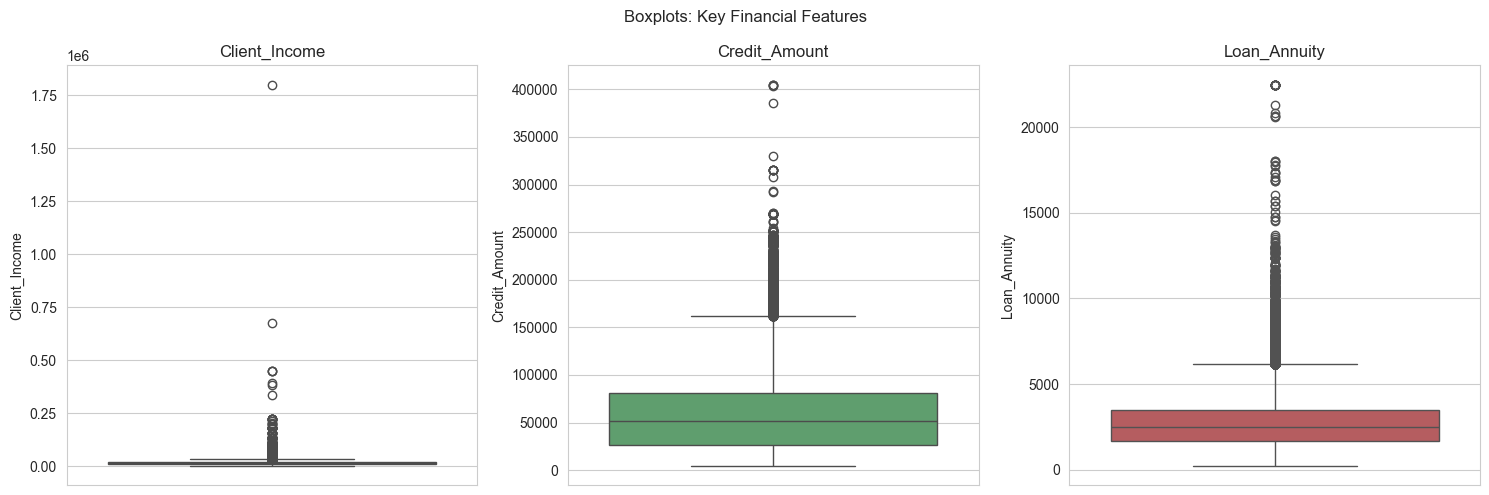

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=eda_df['Client_Income'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Client_Income')

sns.boxplot(y=eda_df['Credit_Amount'], ax=axes[1], color='#55A868')
axes[1].set_title('Credit_Amount')

sns.boxplot(y=eda_df['Loan_Annuity'], ax=axes[2], color='#C44E52')
axes[2].set_title('Loan_Annuity')

fig.suptitle('Boxplots: Key Financial Features')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '05_financial_features_boxplots.png'), dpi=150)
plt.show()

**Interpretation:** all three distributions are right-skewed with a long tail of high-value applicants — the classic shape for income/credit/loan-size data. The boxes (25th–75th percentile) are tight and low relative to the whisker length, confirming most applicants cluster around modest values while a smaller group of higher earners/higher-credit applicants stretches the range. Nothing here looks like a data error.


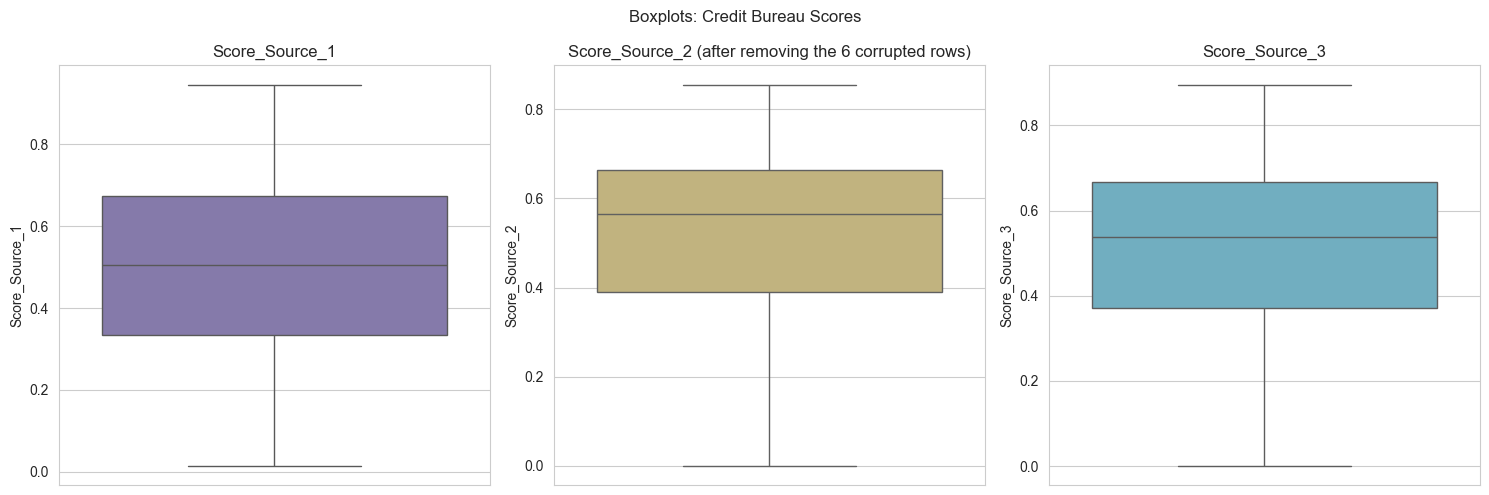

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=eda_df['Score_Source_1'], ax=axes[0], color='#8172B2')
axes[0].set_title('Score_Source_1')

sns.boxplot(y=eda_df['Score_Source_2'], ax=axes[1], color='#CCB974')
axes[1].set_title('Score_Source_2 (after removing the 6 corrupted rows)')

sns.boxplot(y=eda_df['Score_Source_3'], ax=axes[2], color='#64B5CD')
axes[2].set_title('Score_Source_3')

fig.suptitle('Boxplots: Credit Bureau Scores')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '05_credit_scores_boxplots.png'), dpi=150)
plt.show()

**Interpretation:** with the 6 corrupted values removed, `Score_Source_2` now shows the same well-behaved 0–1 range and shape as `Score_Source_1` and `Score_Source_3` — confirming the fix from Section 5.1 was correct and these three features are now consistent and comparable.

### Summary of Section 5 decisions
1. `Score_Source_2 > 1` (6 rows) → treat as missing.
2. `Population_Region_Relative > 1` (2 rows) → treat as missing.
3. Financial features (`Client_Income`, `Credit_Amount`, `Loan_Annuity`) are right-skewed with genuine high-value outliers, not errors — candidates for log-transform/capping (not removal) in preprocessing.
4. `Social_Circle_Default` and `Credit_Bureau` are sparse count-like variables where IQR-flagged "outliers" are expected — no action needed beyond what's already planned for missing values.
